In [1]:
import numpy as np
import torch

import os
from tqdm import tqdm
import sys
sys.path.append("..")
from sklearn.decomposition import PCA
from CricaVPR.dataloaders.train.GSVCitiesDataset import GSVCitiesDataset
from datasets_ws import BaseDataset,TripletsDataset
import torchvision.transforms as T
from torch.utils.data.dataset import Subset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
from util import boq_output_only_model
from tqdm import tqdm

np.random.seed(0)

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]=str(6)
train_data='gsv'
method='crica'
dataset='nordland'
lr=1e-7
num="17" 
patience=None
saved_path_log= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
saved_path_model= f"../logs/best_model_{train_data}_{method}/{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
# saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
logfile=torch.load(saved_path_log)
args=logfile['args']
original_model=True

In [3]:
method="boq"

if method=="boq":
    image_size=[322,322]
    descriptors_dimension = 12288

        
    model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name="dinov2", output_dim=12288)
    
    model=boq_output_only_model(model)
#     for param in model.backbone.named_parameters():
#         if param[1].requires_grad:
#             param[1].requires_grad=False

    
elif method == "crica":
    image_size=[224,224]
    descriptors_dimension = 10752
    model=torch.hub.load("Lu-Feng/CricaVPR", "trained_model")
    args.features_dim=descriptors_dimension
elif method == "salad":
    image_size=[322,322]
    descriptors_dimension=8448
    features_dim=descriptors_dimension
    model = torch.hub.load("serizba/salad", "dinov2_salad")
    
    

model.cuda()
model.eval()

Using cache found in /home/osverburg/.cache/torch/hub/amaralibey_bag-of-queries_main
Using cache found in /home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [3]:
dataset_name="eynsham"
wanted_query_id=2
import pickle as pk
amount_of_test_features=1000000
use_queries=True
args.infer_batch_size=16
n_batches=int(amount_of_test_features//args.infer_batch_size)

In [5]:
def create_features(model):
    batch_id=-1
    with torch.no_grad():
        print("Extracting database features for evaluation")
        # For database use "hard_resize", although it usually has no effect because database images have same resolution
        eval_ds.test_method = "hard_resize"
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, num_workers=args.num_workers,
                                         batch_size=args.infer_batch_size, pin_memory=(args.device == "cuda"))

        idx=np.linspace(0,len(database_dataloader)-1,len(database_dataloader))
    #         print(idx.shape)

        database_features=[None]*(min(n_batches,len(idx)))
        queries_features=[None]*(min(n_batches,len(idx)))
        choices=list(np.random.choice(idx,min(len(idx),n_batches),replace=False))

    #         if test_method == "nearest_crop" or test_method == 'maj_voting':
    #             all_features = np.empty((5 * eval_ds.queries_num + eval_ds.database_num, args.features_dim), dtype="float32")
    #         else:
    #             all_features = np.empty((len(eval_ds), args.features_dim), dtype="float32")

        for i, (inputs, indices) in tqdm(enumerate(database_dataloader)):
            if i not in choices:
                continue
            batch_id+=1
            features = model(inputs.to(args.device))
            features = features.cpu().numpy()
            database_features[batch_id]=features

        print("Extracting queries features for evaluation")
        queries_infer_batch_size = 1 if test_method == "single_query" else args.infer_batch_size
        eval_ds.test_method = test_method
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, num_workers=args.num_workers,
                                        batch_size=queries_infer_batch_size, pin_memory=(args.device == "cuda"))

        batch_id=-1
        if use_queries:
            for i, (inputs, indices) in tqdm(enumerate(queries_dataloader)):
                if i not in choices:
                    continue
                batch_id+=1
                features = model(inputs.to(args.device))
                features = features.cpu().numpy()
                queries_features[batch_id]=features

    database_features = np.vstack(database_features)
    queries_features  = np.vstack(queries_features)
    return database_features, queries_features

In [4]:

batch_id=-1
print(f"extracting features of {dataset_name}")
eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
test_method=args.test_method
model = model.eval()

original_database, original_queries= create_features(model)


state_dict=torch.load("../final_models/best_model_gsv_boq_finetuned_on_eynsham_1e-07_1.pth")["model_state_dict"]
model.load_state_dict(state_dict)
model.eval()

finetuned_database, fine_tuned_queries = create_features(model)


extracting features of eynsham


NameError: name 'model' is not defined

In [8]:
all_features=np.vstack([original_database, original_queries, finetuned_database, fine_tuned_queries])

os.environ["MKL_NUM_THREADS"]      = str(6)                                             # num of threads
os.environ["NUMEXPR_NUM_THREADS"]  = str(6)                                             # num of threads
os.environ["OMP_NUM_THREADS"]      = str(6)                                            # num of threads
pca_compos=512
# dim_reduction=PCA(n_components=pca_compos)
# dim_reduction.fit(all_features)
# small_original=dim_reduction.transform(np.vstack([original_database, original_queries]))
small_fine_tuned=dim_reduction.transform(np.vstack([finetuned_database, fine_tuned_queries]))

In [11]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Initialize t-SNE
perplexity=100
tsne = TSNE(n_components=2,perplexity=perplexity, random_state=0,verbose=1,n_iter=10000,n_jobs=6)

# Fit and transform the data
# tsne_original = tsne.fit_transform(small_original)
tsne_finetuned=  tsne.fit_transform(small_fine_tuned)

eynsham_boq_both=np.array([tsne_original,tsne_finetuned])
np.save("eynsham_boq.npy",eynsham_boq_both)

[t-SNE] Computing 301 nearest neighbors...
[t-SNE] Indexed 47870 samples in 3.857s...
[t-SNE] Computed neighbors for 47870 samples in 365.777s...
[t-SNE] Computed conditional probabilities for sample 1000 / 47870
[t-SNE] Computed conditional probabilities for sample 2000 / 47870
[t-SNE] Computed conditional probabilities for sample 3000 / 47870
[t-SNE] Computed conditional probabilities for sample 4000 / 47870
[t-SNE] Computed conditional probabilities for sample 5000 / 47870
[t-SNE] Computed conditional probabilities for sample 6000 / 47870
[t-SNE] Computed conditional probabilities for sample 7000 / 47870
[t-SNE] Computed conditional probabilities for sample 8000 / 47870
[t-SNE] Computed conditional probabilities for sample 9000 / 47870
[t-SNE] Computed conditional probabilities for sample 10000 / 47870
[t-SNE] Computed conditional probabilities for sample 11000 / 47870
[t-SNE] Computed conditional probabilities for sample 12000 / 47870
[t-SNE] Computed conditional probabilities for 

NameError: name 'eynsham_boq_bothsham_boq_both' is not defined

In [12]:

eynsham_boq_both=np.array([tsne_original,tsne_finetuned])
np.save("eynsham_boq.npy",eynsham_boq_both)

In [5]:

eynsham_boq_both=np.load("eynsham_boq.npy")

In [11]:
original=eynsham_boq_both[0].T
fine_tuned=eynsham_boq_both[1].T

In [ ]:
for i in range(len(eval_ds.soft_positives_per_query)):
    eval_ds.soft_positives_per_query=

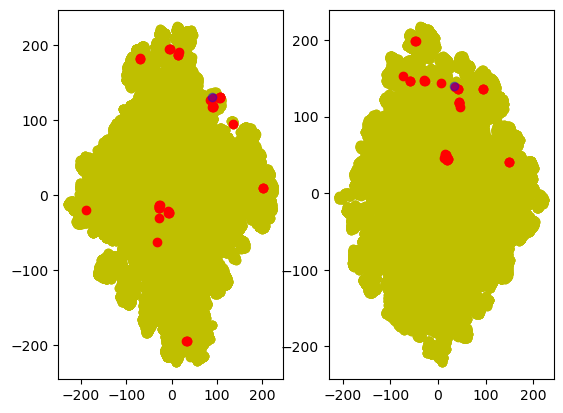

In [40]:
id_to_view=16074
figure,(ax0,ax1)=plt.subplots(1,2)
ax0.scatter(original[0,:eval_ds.database_num],original[1,:eval_ds.database_num],c='y')
ax0.scatter(original[0,eval_ds.database_num:],original[1,eval_ds.database_num:],c='y')

ax0.scatter(original[0,eval_ds.soft_positives_per_query[id_to_view]],original[1,eval_ds.soft_positives_per_query[id_to_view]],c='r')

ax0.scatter(original[0,id_to_view],original[1,id_to_view],c='b',alpha=0.4)

ax1.scatter(fine_tuned[0,:eval_ds.database_num],fine_tuned[1,:eval_ds.database_num],c='y')
ax1.scatter(fine_tuned[0,eval_ds.database_num:],fine_tuned[1,eval_ds.database_num:],c='y')

ax1.scatter(fine_tuned[0,eval_ds.soft_positives_per_query[id_to_view]],fine_tuned[1,eval_ds.soft_positives_per_query[id_to_view]],c='r')

ax1.scatter(fine_tuned[0,id_to_view],fine_tuned[1,id_to_view],c='b',alpha=0.4)


In [ ]:
# Plot the t-SNE results
figure = plt.figure(figsize=(8, 8))
datasets_features
num=0
dataset_tsne={}
im_id=
for data_num in range(0,4):
    
for dataset_name in list(datasets_features.keys()):
    num_prev=num
#     if dataset_name == 'train':
#         continue
    num+=len(datasets_features[dataset_name])
    dataset_tsne[dataset_name]=tsne_results[num_prev:num]
    plt.scatter(tsne_results[num_prev:num, 0], tsne_results[num_prev:num, 1], label=nice_names[dataset_name],alpha=0.5)

plt.legend()
plt.title('DINOv2-BoQ')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
# plt.savefig(f"imgs/tsne_{method}_train_last_pca_{pca_compos}-{amount_of_test_features}imgs-{perplexity}per{'_withqueries' if use_queries else ''}.png",bbox_inches="tight")

plt.show()
figure2 = plt.figure(figsize=(8, 8))
for dataset_name in list(dataset_tsne.keys())[::-1]:
    plt.scatter(dataset_tsne[dataset_name][:,0], dataset_tsne[dataset_name][:,1], label=nice_names[dataset_name],alpha=0.1)
             
    


# plt.scatter(tsne_results[-len(datasets_features["train"]):, 0], tsne_results[-len(datasets_features["train"]):, 1], label="train data")
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1], label="train data")
    
plt.legend()
plt.title('DINOv2-BoQ')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
# plt.savefig(f"imgs/tsne_{method}_pca_{pca_compos}-{amount_of_test_features}imgs-{perplexity}per{'_withqueries' if use_queries else ''}.png",bbox_inches="tight")
plt.show()